In [88]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from utils.helpers import encode_data, f1_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping

pd.set_option('display.max_columns', None)

df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
# df = encode_data(df)

features = df.drop(columns=["customerID", "Churn"])
target = df["Churn"]    

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [49]:
features.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,7043.0,0.504756,0.500013,0.00,0.00,1.00,1.00,1.00
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
Partner,7043.0,0.483033,0.499748,0.00,0.00,0.00,1.00,1.00
Dependents,7043.0,0.299588,0.458110,0.00,0.00,0.00,1.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
PhoneService,7043.0,0.903166,0.295752,0.00,1.00,1.00,1.00,1.00
MultipleLines,7043.0,0.615505,0.656039,0.00,0.00,1.00,1.00,2.00
OnlineSecurity,7043.0,0.720006,0.796885,0.00,0.00,1.00,1.00,2.00
OnlineBackup,7043.0,0.778220,0.778472,0.00,0.00,1.00,1.00,2.00
DeviceProtection,7043.0,0.777226,0.778826,0.00,0.00,1.00,1.00,2.00


In [77]:
df.Contract.unique()

array([0, 1, 2])

Tenure, MonthlyCharges, and TotalCharges have a big peak2peak. need feat scaling. 

In [52]:
scaler = StandardScaler()
cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

features_scaled = features.copy()
features_scaled[cols] = scaler.fit_transform(features[cols])


features_scaled[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,-2.421273e-17,1.000071,-1.318165,-0.951682,-0.137274,0.921455,1.613701
MonthlyCharges,7043.0,-6.406285e-17,1.000071,-1.545860,-0.972540,0.185733,0.833833,1.794352
TotalCharges,7043.0,-3.783239e-17,1.000071,-1.005780,-0.829946,-0.390528,0.664803,2.825806


In [53]:
x_train, x_test, y_train, y_test = train_test_split(features_scaled, target, test_size= 0.2, random_state= 42)

In [75]:
model = Sequential([
    Dense(units=64, activation='relu'),
    Dense(units=32, activation='relu'),
    Dense(units=16, activation='relu'),
    Dense(units=1, activation='linear'),
]
)

model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer= tf.keras.optimizers.Adam(0.01)
)

model.fit(x_train, y_train, epochs= 35, validation_split= 0.2)

Epoch 1/35


141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4527 - val_loss: 0.4118
Epoch 2/35
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4344 - val_loss: 0.4084
Epoch 3/35
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4272 - val_loss: 0.4055
Epoch 4/35
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4253 - val_loss: 0.4096
Epoch 5/35
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4218 - val_loss: 0.4137
Epoch 6/35
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4192 - val_loss: 0.4172
Epoch 7/35
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4189 - val_loss: 0.4162
Epoch 8/35
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4160 - val_loss: 0.4130
Epoch 9/35
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4151 - val_loss: 0.4200
Epoch 10/35
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4092 - val_loss: 0.4183
Epoch 11/35
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4088 - val_loss: 0.4186
Epoch 12/35
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.

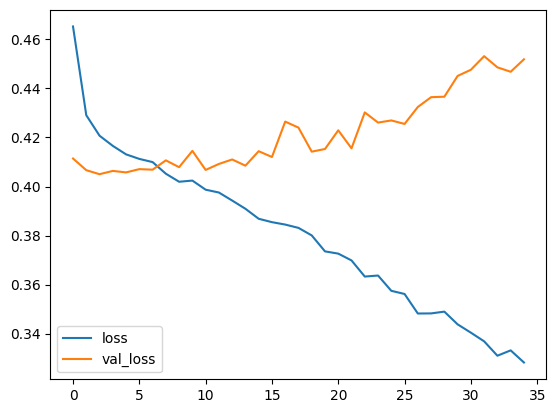

In [73]:
# CHOOSING HYPE PARAMS
loss = model.history.history['loss']
val_loss = model.history.history['val_loss']


plt.plot(loss, label='loss')
plt.plot(val_loss, label='val_loss')
plt.legend()
plt.show()

In [74]:
y_train_pred_proba = tf.sigmoid(model.predict(x_train)).numpy()
y_test_pred_proba = tf.sigmoid(model.predict(x_test)).numpy()
print(y_train_pred_proba.shape)
print(y_test_pred_proba)
y_train_pred = np.where(y_train_pred_proba > 0.5, 1, 0)
y_test_pred = np.where(y_test_pred_proba > 0.5, 1, 0)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Train Accuracy: {train_accuracy}")
print(f"Test Accuracy: {test_accuracy}")

print(y_train_pred[:,0].shape)
print(y_test_pred[:,0].shape)
print(y_train.shape)
f1_train, precision_train, recall_train = f1_score(y_train, y_train_pred[:,0])
f1_test, precision_test, recall_test = f1_score(y_test, y_test_pred[:,0])

print(f"Train F1 Score: {f1_train}, Precision: {precision_train}, Recall: {recall_train}")
print(f"Test F1 Score: {f1_test}, Precision: {precision_test}, Recall: {recall_test}")

177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
(5634, 1)
[[0.5294413 ]
 [0.1447506 ]
 [0.00654298]
 ...
 [0.02533217]
 [0.00158531]
 [0.66673017]]
Train Accuracy: 0.8459353922612709
Test Accuracy: 0.7821149751596878
(5634,)
(1409,)
(5634,)
Train F1 Score: 0.6952247191011236, Precision: 0.6617647058823529, Recall: 0.7322485207100592
Test F1 Score: 0.5518248175182482, Precision: 0.5067024128686327, Recall: 0.6057692307692307


In [26]:
y_train.dtypes

dtype('int64')